In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5


In [2]:
!pip install segmentation-models-pytorch 

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ تم التجهيز بنجاح. الجهاز المستخدم: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
✅ تم التجهيز بنجاح. الجهاز المستخدم: cuda


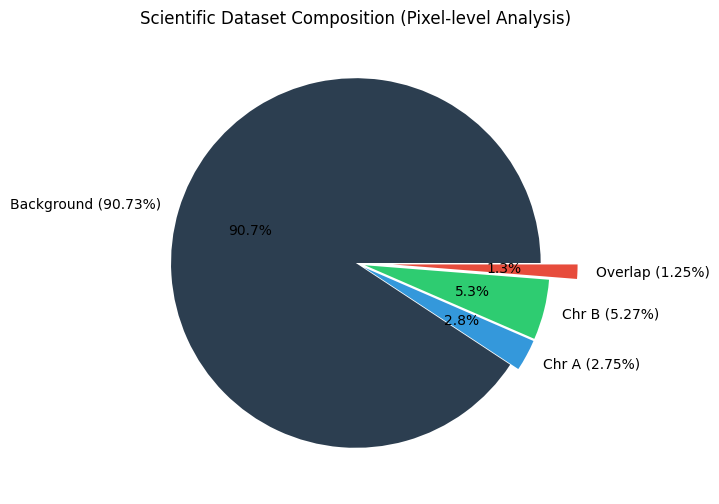

💡 الأوزان المحسوبة لمعالجة عدم التوازن: [ 0.27554438  9.0847324   4.74627225 19.97839221]


In [3]:
file_path = '/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5'

def run_comprehensive_eda(path):
    with h5py.File(path, 'r') as f:
        dataset = f['dataset_1']
        counts = np.zeros(4)
        for i in range(0, len(dataset), 2000):
            batch = dataset[i:min(i+2000, len(dataset)), :, :, 1]
            vals, b_counts = np.unique(batch, return_counts=True)
            for v, c in zip(vals, b_counts):
                if v < 4: counts[int(v)] += c
    
    classes = ['Background', 'Chr A', 'Chr B', 'Overlap']
    percentages = (counts / sum(counts)) * 100
    
    plt.figure(figsize=(10, 6))
    plt.pie(percentages, labels=[f'{c} ({p:.2f}%)' for c, p in zip(classes, percentages)], 
            explode=(0, 0.05, 0.05, 0.2), autopct='%1.1f%%', colors=['#2c3e50', '#3498db', '#2ecc71', '#e74c3c'])
    plt.title("Scientific Dataset Composition (Pixel-level Analysis)")
    plt.show()
    
    weights = sum(counts) / (len(counts) * counts)
    return weights

final_weights = run_comprehensive_eda(file_path)
print(f"💡 الأوزان المحسوبة لمعالجة عدم التوازن: {final_weights}")

In [4]:
class ChromosomeScientificDataset(Dataset):
    def __init__(self, file_path, indices, transform=None):
        self.file_path = file_path
        self.indices = indices
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        with h5py.File(self.file_path, 'r') as f:
            data = f['dataset_1'][real_idx]
            img, msk = data[:,:,0].astype(np.uint8), data[:,:,1].astype(np.uint8)
            msk[msk > 3] = 0
        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']
        img = img.float() / 255.0
        if img.ndim == 2: img = img.unsqueeze(0)
        msk_oh = F.one_hot(msk.long(), 4).permute(2, 0, 1).float()
        return img, msk_oh

# تقسيم البيانات (70% تدريب، 15% تحقق، 15% اختبار)
total_indices = np.arange(13434)
train_idx, temp_idx = random_split(total_indices, [0.7, 0.3], generator=torch.Generator().manual_seed(42))
val_idx, test_idx = random_split(temp_idx, [0.5, 0.5], generator=torch.Generator().manual_seed(42))

train_trans = A.Compose([A.Resize(128, 128), A.Rotate(limit=30, p=0.5), A.HorizontalFlip(p=0.5), ToTensorV2()])
test_trans = A.Compose([A.Resize(128, 128), ToTensorV2()])

train_loader = DataLoader(ChromosomeScientificDataset(file_path, train_idx.indices, train_trans), batch_size=32, shuffle=True)
val_loader = DataLoader(ChromosomeScientificDataset(file_path, val_idx.indices, test_trans), batch_size=32)
test_loader = DataLoader(ChromosomeScientificDataset(file_path, test_idx.indices, test_trans), batch_size=32)

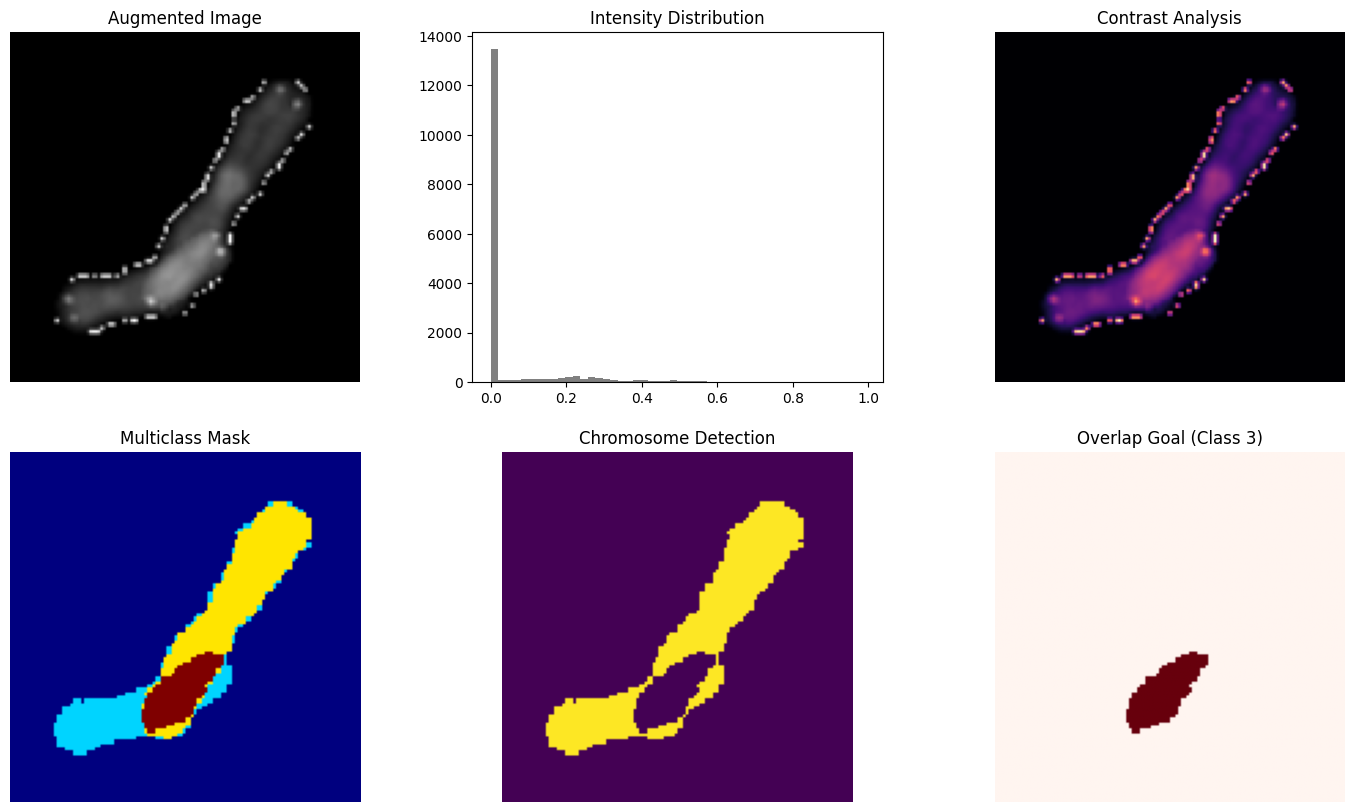

In [6]:
def visualize_detailed_logic(loader):
    imgs, msks = next(iter(loader))
    img, msk = imgs[0].squeeze().cpu().numpy(), torch.argmax(msks[0], 0).cpu().numpy()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title("Augmented Image")
    axes[0,1].hist(img.flatten(), bins=50, color='gray'); axes[0,1].set_title("Intensity Distribution")
    axes[0,2].imshow(img, cmap='magma'); axes[0,2].set_title("Contrast Analysis")
    
    axes[1,0].imshow(msk, cmap='jet'); axes[1,0].set_title("Multiclass Mask")
    axes[1,1].imshow(np.isin(msk, [1, 2]), cmap='viridis'); axes[1,1].set_title("Chromosome Detection")
    axes[1,2].imshow(msk == 3, cmap='Reds'); axes[1,2].set_title("Overlap Goal (Class 3)")
    
    for ax in axes.flatten(): ax.axis('off')
    axes[0,1].axis('on')
    plt.show()

visualize_detailed_logic(train_loader)

In [7]:
class VGGBlock(nn.Module):
    def __init__(self, in_c, mid_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, mid_c, 3, padding=1), nn.BatchNorm2d(mid_c), nn.ReLU(inplace=True),
            nn.Conv2d(mid_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class UNetPlusPlusFinal(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        nb = [32, 64, 128, 256, 512]
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        self.con0_0 = VGGBlock(1, nb[0], nb[0])
        self.con1_0 = VGGBlock(nb[0], nb[1], nb[1])
        self.con0_1 = VGGBlock(nb[0]+nb[1], nb[0], nb[0])
        self.con2_0 = VGGBlock(nb[1], nb[2], nb[2])
        self.con1_1 = VGGBlock(nb[1]+nb[2], nb[1], nb[1])
        self.con0_2 = VGGBlock(nb[0]*2+nb[1], nb[0], nb[0])
        self.con3_0 = VGGBlock(nb[2], nb[3], nb[3])
        self.con2_1 = VGGBlock(nb[2]+nb[3], nb[2], nb[2])
        self.con1_2 = VGGBlock(nb[1]*2+nb[2], nb[1], nb[1])
        self.con0_3 = VGGBlock(nb[0]*3+nb[1], nb[0], nb[0])
        self.con4_0 = VGGBlock(nb[3], nb[4], nb[4])
        self.con3_1 = VGGBlock(nb[3]+nb[4], nb[3], nb[3])
        self.con2_2 = VGGBlock(nb[2]*2+nb[3], nb[2], nb[2])
        self.con1_3 = VGGBlock(nb[1]*3+nb[2], nb[1], nb[1])
        self.con0_4 = VGGBlock(nb[0]*4+nb[1], nb[0], nb[0])
        self.final = nn.Conv2d(nb[0], num_classes, kernel_size=1)

    def forward(self, x):
        x0_0 = self.con0_0(x)
        x1_0 = self.con1_0(self.pool(x0_0)); x0_1 = self.con0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x2_0 = self.con2_0(self.pool(x1_0)); x1_1 = self.con1_1(torch.cat([x1_0, self.up(x2_0)], 1)); x0_2 = self.con0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x3_0 = self.con3_0(self.pool(x2_0)); x2_1 = self.con2_1(torch.cat([x2_0, self.up(x3_0)], 1)); x1_2 = self.con1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1)); x0_3 = self.con0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x4_0 = self.con4_0(self.pool(x3_0)); x3_1 = self.con3_1(torch.cat([x3_0, self.up(x4_0)], 1)); x2_2 = self.con2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1)); x1_3 = self.con1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1)); x0_4 = self.con0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))
        return self.final(x0_4)

model = UNetPlusPlusFinal().to(device)

Epoch 1/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/294 [00:00<?, ?it/s]

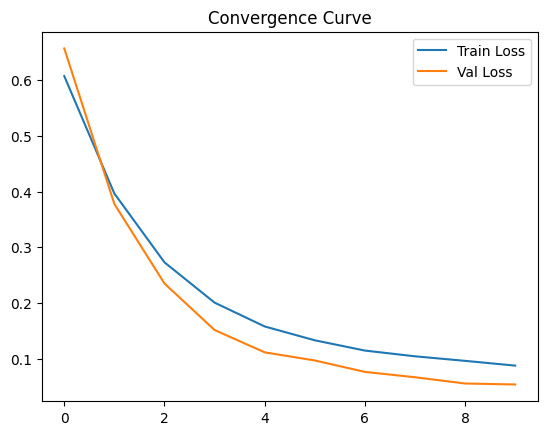

In [8]:
weights_t = torch.tensor(final_weights, dtype=torch.float).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, 11):
    model.train()
    running_t = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/10")
    for i, m in pbar:
        i, m = i.to(device), m.to(device)
        optimizer.zero_grad()
        out = model(i)
        ce = F.cross_entropy(out, torch.argmax(m, 1), weight=weights_t)
        dice = 1 - (2.*(F.softmax(out, 1)*m).sum() / (F.softmax(out, 1).sum() + m.sum() + 1e-6))
        loss = 0.5 * ce + 0.5 * dice
        loss.backward(); optimizer.step(); running_t += loss.item()
        pbar.set_postfix(loss=f"{running_t/len(train_loader):.4f}")
    
    model.eval()
    val_l = sum(F.cross_entropy(model(i.to(device)), torch.argmax(m.to(device), 1)).item() for i, m in val_loader)/len(val_loader)
    history['train_loss'].append(running_t/len(train_loader)); history['val_loss'].append(val_l)

plt.plot(history['train_loss'], label='Train Loss'); plt.plot(history['val_loss'], label='Val Loss')
plt.title("Convergence Curve"); plt.legend(); plt.show()

Testing:   0%|          | 0/63 [00:00<?, ?it/s]

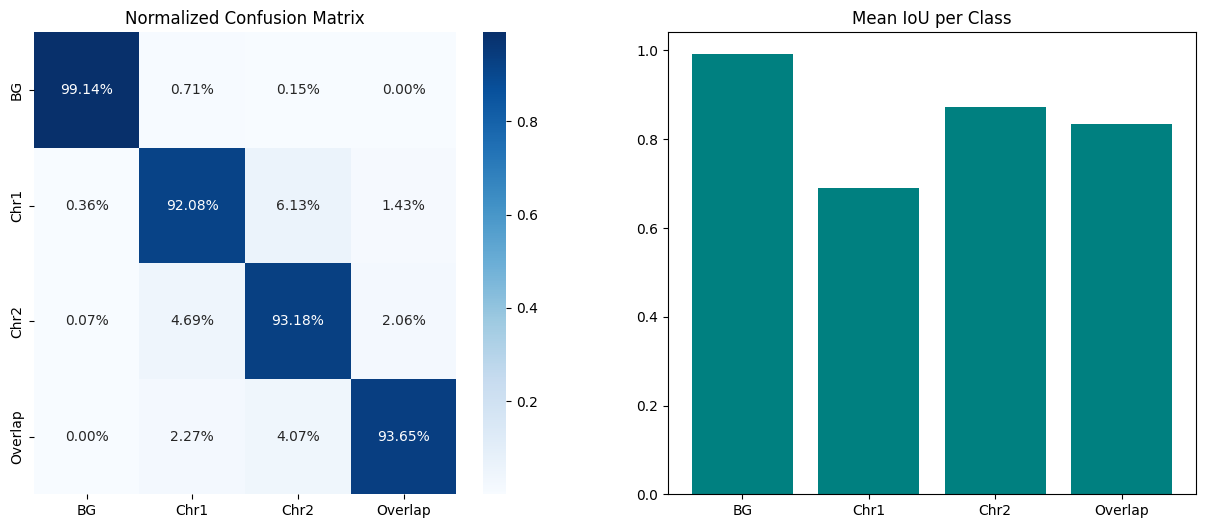

,precision,recall,f1-score,support
Background,0.9998,0.9914,0.9956,2.994119e+07
Chr 1,0.7343,0.9208,0.8170,9.111870e+05
Chr 2,0.9331,0.9318,0.9325,1.751971e+06
Overlap Area,0.8843,0.9365,0.9097,4.094080e+05
accuracy,0.9856,0.9856,0.9856,9.856000e-01
macro avg,0.8879,0.9451,0.9137,3.301376e+07
weighted avg,0.9875,0.9856,0.9863,3.301376e+07


In [9]:
def run_final_analytics(model, loader):
    model.eval()
    all_p, all_t = [], []
    iou = np.zeros(4)
    with torch.no_grad():
        for i, m in tqdm(loader, desc="Testing"):
            i, m = i.to(device), m.to(device)
            preds = torch.argmax(model(i), 1)
            targets = torch.argmax(m, 1)
            all_p.extend(preds.cpu().numpy().flatten())
            all_t.extend(targets.cpu().numpy().flatten())
            for c in range(4):
                iou[c] += ((preds==c)&(targets==c)).sum().item() / (((preds==c)|(targets==c)).sum().item()+1e-6)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(confusion_matrix(all_t, all_p, normalize='true'), annot=True, fmt='.2%', cmap='Blues', ax=ax[0],
                xticklabels=['BG','Chr1','Chr2','Overlap'], yticklabels=['BG','Chr1','Chr2','Overlap'])
    ax[0].set_title("Normalized Confusion Matrix")
    
    ax[1].bar(['BG','Chr1','Chr2','Overlap'], iou/len(loader), color='teal')
    ax[1].set_title("Mean IoU per Class")
    plt.show()

 
    report = classification_report(all_t, all_p, target_names=['Background', 'Chr 1', 'Chr 2', 'Overlap Area'], output_dict=True)
    display(pd.DataFrame(report).transpose().round(4))

run_final_analytics(model, test_loader)